# 05 · Analyze, Part C: which channels deserve the credit? (D1)

**Decision D1:** how should the Head of Marketing shift channel budget?

The store's GA channel report uses **last non-direct click**. When a visitor comes back by bookmark or typed URL, GA labels that visit with their *previous* campaign ([Process](../reports/03_process.md)). This notebook compares that report with five attribution models run on the channels visitors **actually arrived through** (decision D-PR1), counting **purchases first and capped revenue second** (D-P2).

Contents: who holds each channel's revenue (the key account) → channel profile → journeys and roles → choosing the Markov model → credit under six models → H2 → how much GA over-credits Organic Search → returning visitors → sensitivity → what a paid click is worth → conclusions.

Full write-up: [reports/04_analyze.md](../reports/04_analyze.md), Part C.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import itertools
import math

import numpy as np
import pandas as pd
from IPython.display import display

from src import bq, viz
from src.attribution import (KEYWORD_CLASSES, MODELS, Attribution, credit_vs_presence, markov_holdout_loglik,
                             search_keyword_class, split_paths, starter_closer)
from src.journeys import PERIOD_END, PERIOD_START, revenue_cap
from src.segments import EMPLOYEES, EXTERNAL, KEY_ACCOUNT, is_key_account, segment
from src.validate import visitor_concentration

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
N_BOOT = 1000
MARKOV_ORDER = 3   # chosen in section 4 by held-out likelihood

sessions = pd.read_parquet(ROOT / "data/raw/sessions_clean.parquet")
sessions["segment"] = segment(sessions)
ext = sessions[sessions.segment == EXTERNAL]   # the marketing population: no employees, no key account
CAP = revenue_cap(sessions)                    # D-P2, set in Process: $1,606 per purchase session

# D1 tables from Process. src/journeys.py leaves key accounts out, like employees; dropping them here also
# covers tables built before that rule. The cap must stay the Process cap.
journeys = pd.read_parquet(ROOT / "data/processed/journeys.parquet")
touches = pd.read_parquet(ROOT / "data/processed/touches.parquet")
journeys = journeys[~is_key_account(journeys.full_visitor_id)].reset_index(drop=True)
touches = touches[~is_key_account(touches.full_visitor_id)].reset_index(drop=True)
assert np.isclose(journeys.revenue_capped_usd.max(), CAP), "journeys were capped at a different value"
print(f"Revenue cap per purchase session: ${CAP:,.2f}")

Revenue cap per purchase session: $1,605.91


## 1. Who holds each channel's revenue?

Before crediting channels, check that no single buyer decides a channel's numbers. The check runs on the outside purchase sessions of the attribution period (journeys ending Aug 31, 2016 – Jul 1, 2017), labeled both as GA's report labels them and by how the visitor actually arrived (`isTrueDirect` → Direct), and flags any buyer holding more than 20% of a channel's revenue ([`src/validate.py`](../src/validate.py)).

In [2]:
outside = sessions[sessions.segment != EMPLOYEES]   # key accounts still in: this check is how they are found
orders = outside[outside.purchased & outside.session_date.between(PERIOD_START, PERIOD_END)].assign(
    arrival_channel=lambda d: d.channel.where(~d.is_true_direct, "Direct"),
    revenue_capped=lambda d: d.revenue_usd.clip(upper=CAP))
parts = {}
for labels, col in [("GA label", "channel"), ("Arrival", "arrival_channel")]:
    raw = visitor_concentration(orders, col)
    capped = visitor_concentration(orders, col, "revenue_capped")
    parts[labels] = raw.assign(top_share_capped=capped.top_share).rename_axis("channel")
concentration = pd.concat(parts, names=["labels"])
print(f"{len(orders):,} purchase sessions, ${orders.revenue_usd.sum():,.0f} of revenue")
concentration[["purchases", "revenue", "top_visitor", "top_share", "top_share_capped", "top_n_share", "flagged"]] \
    .style.format({"purchases": "{:,}", "revenue": "${:,.0f}", "top_share": "{:.1%}", "top_share_capped": "{:.1%}",
                   "top_n_share": "{:.1%}", "flagged": ", ".join})

5,074 purchase sessions, $850,184 of revenue


In [3]:
aff = orders[orders.channel.eq("Affiliates")].groupby("full_visitor_id").revenue_usd.sum().sort_values(ascending=False)
print(f"Affiliates by GA label: {int(orders.channel.eq('Affiliates').sum())} purchase sessions, ${aff.sum():,.0f} (${aff.sum():,.2f}). "
      "Each buyer's share: " + ", ".join(f"{v} {s:.1%} ({s:.4f})" for v, s in (aff / aff.sum()).items()))

Affiliates by GA label: 3 purchase sessions, $54 ($53.95). Each buyer's share: 6946322182542883504 57.4% (0.5744), 0729769598575814527 24.1% (0.2408), 5580729161862830702 18.5% (0.1848)


`top_share` is the largest buyer's share of the channel's revenue (`top_share_capped` after capping each purchase session at USD 1,606), `top_n_share` the five largest buyers' together, and `flagged` every buyer above 20%.

**One visitor holds 89% of the revenue GA credits to Display** (USD 110,553 of USD 124,483; 57% after capping). It is also the largest buyer behind Direct, with 19% of the revenue on direct arrivals. The other flags are small channels where one ordinary buyer stands out: Referral and Social (a quarter of USD 31k and of USD 6k), Affiliates (USD 54 in all), (Other) (one USD 12 purchase), and, by arrival channel, one Referral and one Display buyer whose share the cap brings under 20%.

### The key account

Visitor 1957458976293878100, in the order of its campaign clicks and purchases:

In [4]:
account = sessions[sessions.segment == KEY_ACCOUNT].sort_values("visit_start_time")
display_click = account.loc[(account.channel == "Display") & ~account.is_true_direct, "visit_start_time"].iloc[0]
events = account[~account.is_true_direct | account.purchased]
timeline = pd.DataFrame({
    "date": events.session_date.dt.date, "visit": events.visit_number,
    "arrived by": np.where(events.is_true_direct.to_numpy(bool), "return visit (isTrueDirect)", "clicked " + events.channel),
    "GA label": events.channel, "transactions": events.transactions, "revenue": events.revenue_usd,
    "days after its Display click": ((events.visit_start_time - display_click) / 86400).round().astype(int)})
display(timeline.style.hide(axis="index").format({"revenue": "${:,.0f}"}))
after = timeline[timeline["GA label"].eq("Display") & timeline.transactions.gt(0)]
print(f"Purchases GA labeled Display: {len(after)}, worth ${after.revenue.sum():,.0f}, "
      f"{after['days after its Display click'].min()}–{after['days after its Display click'].max()} days after its only Display click")

labels = account.groupby("channel").session_date.agg(["min", "max", "size"]).sort_values("min")
print("GA's label on its sessions: " + "; ".join(f"{c} {r['min']:%b %d, %Y} – {r['max']:%b %d, %Y} ({r['size']} sessions)"
                                                  for c, r in labels.iterrows()))
local = account.session_start.dt.tz_convert("America/Los_Angeles")
setup = account[["device_category", "operating_system", "browser", "country"]].drop_duplicates()
print(f"{len(account)} sessions from {len(setup)} setup ({', '.join(setup.iloc[0])}); {(local.dt.dayofweek < 5).mean():.0%} on "
      f"weekdays, {local.dt.hour.between(4, 13).mean():.0%} starting 7 am – 5 pm US Eastern")

date,visit,arrived by,GA label,transactions,revenue,days after its Display click
2016-08-04,38,clicked Organic Search,Organic Search,0,$0,-218
2017-02-14,181,return visit (isTrueDirect),Direct,1,"$17,860",-24
2017-03-10,226,clicked Display,Display,0,$0,0
2017-03-24,237,return visit (isTrueDirect),Display,1,"$8,681",14
2017-04-05,243,return visit (isTrueDirect),Display,2,"$47,082",26
2017-04-07,245,return visit (isTrueDirect),Display,1,"$6,832",28
2017-04-07,246,return visit (isTrueDirect),Display,1,"$3,030",28
2017-04-18,258,return visit (isTrueDirect),Display,3,"$32,154",39
2017-04-19,259,return visit (isTrueDirect),Display,1,"$3,678",40
2017-05-26,293,return visit (isTrueDirect),Display,1,$417,77


Purchases GA labeled Display: 15, worth $110,553, 14–112 days after its only Display click
GA's label on its sessions: Organic Search Aug 04, 2016 – Feb 02, 2017 (136 sessions); Direct Feb 07, 2017 – Mar 10, 2017 (46 sessions); Display Mar 10, 2017 – Aug 01, 2017 (96 sessions)
278 sessions from 1 setup (desktop, Windows, Firefox, United States); 99% on weekdays, 97% starting 7 am – 5 pm US Eastern


In [5]:
in_period = sessions.session_date.between(PERIOD_START, PERIOD_END)
buys = sessions[in_period & sessions.purchased & (sessions.segment != EMPLOYEES)]
segments = buys.groupby("segment").agg(
    visitors=("full_visitor_id", "nunique"), purchase_sessions=("purchased", "size"), transactions=("transactions", "sum"),
    revenue=("revenue_usd", "sum"), revenue_capped=("revenue_usd", lambda r: r.clip(upper=CAP).sum()))
segments["share_of_revenue"] = segments.revenue / segments.revenue.sum()
segments["share_of_capped_revenue"] = segments.revenue_capped / segments.revenue_capped.sum()
print("Outside purchase sessions in the attribution period, by segment:")
segments.loc[[EXTERNAL, KEY_ACCOUNT]].style.format({
    "visitors": "{:,}", "purchase_sessions": "{:,}", "transactions": "{:,}", "revenue": "${:,.0f}",
    "revenue_capped": "${:,.0f}", "share_of_revenue": "{:.1%}", "share_of_capped_revenue": "{:.1%}"})

Outside purchase sessions in the attribution period, by segment:


,visitors,purchase_sessions,transactions,revenue,revenue_capped,share_of_revenue,share_of_capped_revenue
segment,,,,,,,
External,"4,462","5,058","5,296","$721,771","$664,824",84.9%,97.3%
Key account,1,16,22,"$128,413","$18,709",15.1%,2.7%


In [6]:
cap_without = revenue_cap(sessions[~is_key_account(sessions.full_visitor_id)])
print(f"Revenue cap per purchase session, as set in Process with the key account: ${CAP:,.0f} (${CAP:,.2f}). "
      f"Without the key account the 99th percentile would be ${cap_without:,.0f} (${cap_without:,.2f}).")

Revenue cap per purchase session, as set in Process with the key account: $1,606 ($1,605.91). Without the key account the 99th percentile would be $1,506 ($1,506.33).


- **It was already a customer before it ever clicked a Display ad.** Its first visit in the data is its 38th. It placed a **USD 17,860 order on Feb 14, 2017**, 24 days before its **only Display click (Mar 10, 2017)**, a visit with no purchase.
- **GA then labeled its next 15 purchases Display.** All were return visits, 14 to 112 days after that click, worth USD 110,553. GA's campaign carry-over (up to 6 months) had done the same before: after an Organic Search click in August 2016, its returns were labeled Organic Search until February 2017.
- **It looks like a business buyer**: 278 sessions from one US desktop, almost all on weekdays in office hours, with purchase sessions up to USD 47,082.

**Decision:** report the account as its own segment, like Google employees ([`src/segments.py`](../src/segments.py)), and leave it out of the D1 journeys ([`src/journeys.py`](../src/journeys.py)). Its USD 128,413 (15.1% of outside revenue in the period, 2.7% after capping) reflects an existing corporate relationship, not what Display or any other channel caused. The revenue cap stays at **USD 1,606** per purchase session, as set in Process with the account included; without it the 99th percentile would fall to about USD 1,506. **Everything below excludes the account.**

### Bulk purchase sessions

The revenue cap applies **per purchase session**, and a session can hold several transactions.

In [7]:
bulk = buys[buys.revenue_usd > CAP]
by_segment = bulk.groupby("segment").agg(
    sessions=("revenue_usd", "size"), visitors=("full_visitor_id", "nunique"),
    several_transactions=("transactions", lambda n: int((n > 1).sum())), revenue=("revenue_usd", "sum"))
by_segment.loc["All outside visitors"] = [len(bulk), bulk.full_visitor_id.nunique(), int((bulk.transactions > 1).sum()),
                                          bulk.revenue_usd.sum()]
by_segment["share_of_bulk_revenue"] = by_segment.revenue / bulk.revenue_usd.sum()
most = bulk.loc[bulk.transactions.idxmax()]
print(f"Bulk purchase sessions (over ${CAP:,.0f}) hold {bulk.revenue_usd.sum() / buys.revenue_usd.sum():.1%} of outside revenue in "
      f"the period. The most transactions in one: {most.transactions} (${most.revenue_usd / most.transactions:,.0f} each). Counted per "
      f"transaction, {int((bulk.revenue_usd / bulk.transactions > CAP).sum())} of {len(bulk)} stay above the cap. Most bulk sessions "
      f"by any other visitor: {bulk[bulk.segment == EXTERNAL].full_visitor_id.value_counts().max()}.")
display(by_segment.style.format({"sessions": "{:,.0f}", "visitors": "{:,.0f}", "several_transactions": "{:,.0f}",
                                 "revenue": "${:,.0f}", "share_of_bulk_revenue": "{:.1%}"}))
print("Without the key account, by GA's channel label:")
bulk[bulk.segment == EXTERNAL].groupby("channel").revenue_usd.agg(sessions="size", revenue="sum", median="median") \
    .sort_values("revenue", ascending=False).style.format({"revenue": "${:,.0f}", "median": "${:,.0f}"})

Bulk purchase sessions (over $1,606) hold 29.2% of outside revenue in the period. The most transactions in one: 25 ($78 each). Counted per transaction, 41 of 51 stay above the cap. Most bulk sessions by any other visitor: 2.


,sessions,visitors,several_transactions,revenue,share_of_bulk_revenue
segment,,,,,
External,42,38,10,"$124,395",50.0%
Key account,9,1,2,"$124,157",50.0%
All outside visitors,51,39,12,"$248,552",100.0%


Without the key account, by GA's channel label:


,sessions,revenue,median
channel,,,
Direct,25,"$80,329","$2,337"
Organic Search,14,"$37,266","$2,217"
Display,2,"$4,431","$2,215"
Referral,1,"$2,370","$2,370"


**51 bulk purchase sessions from 39 visitors** hold USD 248,552 (29.2% of outside revenue in the period). **The key account has 9 of them, half of the bulk revenue.** Twelve hold several transactions, one of them 25 small orders (USD 78 each), so a "bulk order" is a large purchase session, not always one large order. Without the account, 42 bulk sessions from 38 visitors remain (USD 124,395), mostly on Direct (25) and Organic Search (14), and no visitor has more than 2.

## 2. Channel profile (outside traffic, as GA labels it)

All outside sessions, Aug 2016 – Aug 2017, without employees or the key account.

In [8]:
profile = ext.assign(revenue_capped=ext.revenue_usd.clip(upper=CAP)).groupby("channel").agg(
    sessions=("session_key", "size"), purchases=("purchased", "sum"),
    revenue=("revenue_usd", "sum"), revenue_capped=("revenue_capped", "sum"))
profile["conversion_rate"] = profile.purchases / profile.sessions
profile["share_of_sessions"] = profile.sessions / profile.sessions.sum()
profile["share_of_purchases"] = profile.purchases / profile.purchases.sum()
relabelled = ext[ext.is_true_direct & ext.channel.ne("Direct")]
print(f"Direct returns that GA labels with an earlier campaign: {len(relabelled):,} of {len(ext):,} sessions "
      f"({len(relabelled) / len(ext):.1%}), holding {int(relabelled.purchased.sum()):,} of {int(ext.purchased.sum()):,} purchases "
      f"({relabelled.purchased.sum() / ext.purchased.sum():.1%})")
profile.sort_values("purchases", ascending=False).style.format({
    "sessions": "{:,}", "purchases": "{:,}", "revenue": "${:,.0f}", "revenue_capped": "${:,.0f}",
    "conversion_rate": "{:.2%}", "share_of_sessions": "{:.1%}", "share_of_purchases": "{:.1%}"})

Direct returns that GA labels with an earlier campaign: 96,579 of 826,839 sessions (11.7%), holding 1,775 of 6,128 purchases (29.0%)


,sessions,purchases,revenue,revenue_capped,conversion_rate,share_of_sessions,share_of_purchases
channel,,,,,,,
Organic Search,"377,796","3,321","$359,690","$331,764",0.88%,45.7%,54.2%
Direct,"139,957","1,965","$456,076","$377,110",1.40%,16.9%,32.1%
Paid Search,"25,070",455,"$46,236","$46,236",1.81%,3.0%,7.4%
Referral,"36,301",177,"$34,053","$33,290",0.49%,4.4%,2.9%
Display,"5,456",113,"$17,108","$15,889",2.07%,0.7%,1.8%
Social,"225,788",87,"$7,530","$7,530",0.04%,27.3%,1.4%
Affiliates,"16,365",9,$654,$654,0.05%,2.0%,0.1%
(Other),106,1,$12,$12,0.94%,0.0%,0.0%


Social brings **27% of outside sessions but 1.4% of purchases**. Display still converts best per session (2.1%), but without the key account it brought only USD 17k of revenue in the year (section 1). About 12% of outside sessions, holding 29% of purchases, are direct returns that GA labels with an earlier campaign (D-PR1).

**The Oct–Nov 2016 traffic spike flagged in Prepare was YouTube:**

In [9]:
yt = ext[ext.source == "youtube.com"].assign(month=lambda d: d.session_date.dt.strftime("%Y-%m"))
print(f"youtube.com over the year: {len(yt):,} sessions, {int(yt.purchased.sum())} purchases")
yt.groupby("month").agg(sessions=("session_key", "size"), purchases=("purchased", "sum")).T

youtube.com over the year: 212,561 sessions, 11 purchases


month,2016-08,2016-09,2016-10,2016-11,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08
sessions,24389,23982,41394,56582,15850,9708,9417,11962,9327,1591,1837,6342,180
purchases,1,1,0,0,0,4,1,1,0,1,1,1,0


`youtube.com` sent 41k and 57k sessions in October and November 2016 with **no purchases**, and about 213k sessions over the year with 11 purchases. Whatever drove that traffic, it brought viewers, not buyers.

## 3. Buying journeys and channel roles

A journey is a visitor's run of visits that ends in a purchase or after 30 days of silence ([Process](../reports/03_process.md)).

In [10]:
conv = journeys[journeys.converted]
differs = conv.arrival_path != conv.ga_path
print(f"{len(journeys):,} journeys, {len(conv):,} with a purchase; "
      f"{(conv.n_touches > 1).mean():.1%} of purchasing journeys have more than one visit, and {differs.sum():,} "
      f"({differs.mean():.1%}) have an arrival path that differs from GA's labels. Revenue ${conv.revenue_usd.sum():,.0f}, "
      f"${conv.revenue_capped_usd.sum():,.0f} after capping.")
roles = starter_closer(journeys)
roles

580,759 journeys, 5,058 with a purchase; 42.4% of purchasing journeys have more than one visit, and 1,498 (29.6%) have an arrival path that differs from GA's labels. Revenue $721,771, $664,824 after capping.


role,starts,closes,assists,start_to_close_ratio
channel,,,,
Direct,1019,1879,945,0.542310
Organic Search,881,129,81,6.829457
Paid Search,164,77,62,2.129870
Display,34,12,21,2.833333
Referral,29,39,34,0.743590
Social,18,11,8,1.636364
Affiliates,2,0,1,NaN
(Other),0,0,1,NaN


In multi-visit purchasing journeys, **Organic Search starts journeys 6.8× as often as it closes them**, as do Display (2.8×), Paid Search (2.1×), and Social (1.6×). **Direct is the closer**: people come back by bookmark or typed URL to buy. That's exactly where single-touch reports disagree.

## 4. Choosing the Markov model

A first-order Markov chain remembers only the current step. So a visitor who came from YouTube and later returns directly is treated like an *average* direct visitor, who buys far more often. Higher orders remember more steps. The order is chosen by how well each chain predicts **later journeys it wasn't fit on** (fit on journeys ending before March 2017, scored on the rest).

In [11]:
paths = split_paths(journeys, "arrival_path")
channels = sorted(set(c for p in paths for c in p) | set(journeys.ga_last_channel))
index = {c: i for i, c in enumerate(channels)}
int_paths = [[index[c] for c in p] for p in paths]
converted = journeys.converted.to_numpy()
early = (journeys.end_date < "2017-03-01").to_numpy()
rows = []
for k in (1, 2, 3):
    ll = markov_holdout_loglik([p for p, e in zip(int_paths, early) if e], converted[early],
                               [p for p, e in zip(int_paths, ~early) if e], converted[~early], len(channels), k)
    chain = Attribution(journeys, "arrival_path", order=k)
    credit = chain.credit_table()[("markov", "conversions")]
    rows.append({"order": k, "states": chain.n_states, "held_out_loglik_per_journey": ll, "Social credit": credit["Social"],
                 "Affiliates credit": credit["Affiliates"], "Paid Search credit": credit["Paid Search"]})
orders = pd.DataFrame(rows).set_index("order")
orders.round(4)

,states,held_out_loglik_per_journey,Social credit,Affiliates credit,Paid Search credit
order,,,,,
1,11,-2.1751,163.4824,28.8370,283.0304
2,73,-2.1342,116.9952,23.2478,332.7112
3,346,-2.1293,88.6001,16.1103,341.3830


In [12]:
first_channel = conv.arrival_path.str.split(" > ").str[0].value_counts()
print(f"Purchasing journeys Social starts: {first_channel['Social']} (it appears in "
      f"{int(conv.arrival_path.str.contains('Social', regex=False).sum())}). Social's Markov credit by chain order, "
      "and as a multiple of those journeys: "
      + "; ".join(f"order {k} {c:.0f} purchases ({c:.1f}), {c / first_channel['Social']:.1f}× ({c / first_channel['Social']:.2f}×)"
                  for k, c in orders["Social credit"].items()))

Purchasing journeys Social starts: 59 (it appears in 75). Social's Markov credit by chain order, and as a multiple of those journeys: order 1 163 purchases (163.5), 2.8× (2.77×); order 2 117 purchases (117.0), 2.0× (1.98×); order 3 89 purchases (88.6), 1.5× (1.50×)


Held-out likelihood improves at every order, most from 1 to 2, and **order 3 fits best**. As memory grows, Social's credit falls from 163 purchases toward what its journeys actually produced (59 purchases in journeys it started), which confirms the first-order bias. All results below use the **third-order chain**. It doesn't remove the bias entirely (section 9).

## 5. Credit under six models (purchases)

In [13]:
att = Attribution(journeys, "arrival_path", order=MARKOV_ORDER)
shares = att.shares()
boot = att.bootstrap_shares(n_boot=N_BOOT, seed=42, clusters=journeys.full_visitor_id)   # resamples visitors
low, high = np.percentile(boot, [2.5, 97.5], axis=0)
names = {"ga_last_click": "GA report", "last_touch": "Last touch", "first_touch": "First touch",
         "linear": "Linear", "position_based": "Position-based", "markov": "Markov (data-driven)"}
order = ["Organic Search", "Direct", "Paid Search", "Referral", "Display", "Social", "Affiliates"]
table = pd.DataFrame({names[m]: [f"{100 * shares.loc[c, m]:.1f}% ({100 * low[att.channels.index(c), k]:.1f}–"
                                 f"{100 * high[att.channels.index(c), k]:.1f})" for c in order]
                      for k, m in enumerate(MODELS)}, index=order)
table

,GA report,Last touch,First touch,Linear,Position-based,Markov (data-driven)
Organic Search,53.8% (51.9–55.5),30.0% (28.6–31.5),44.9% (43.3–46.5),35.8% (34.4–37.3),36.7% (35.3–38.2),38.2% (37.2–39.4)
Direct,32.6% (30.8–34.5),60.9% (59.4–62.5),43.9% (42.1–45.7),54.2% (52.6–55.7),53.2% (51.6–54.8),49.3% (48.1–50.5)
Paid Search,7.5% (6.7–8.3),5.6% (5.0–6.2),7.3% (6.6–8.0),6.4% (5.7–7.0),6.4% (5.8–7.1),6.7% (6.2–7.4)
Referral,3.0% (2.4–3.6),1.4% (1.1–1.7),1.2% (0.9–1.5),1.3% (1.1–1.6),1.3% (1.1–1.6),2.2% (1.9–2.5)
Display,1.6% (1.3–2.0),1.0% (0.7–1.3),1.4% (1.1–1.8),1.2% (0.9–1.5),1.2% (0.9–1.5),1.4% (1.1–1.7)
Social,1.5% (1.2–1.9),1.0% (0.8–1.3),1.2% (0.9–1.5),1.1% (0.8–1.4),1.1% (0.8–1.4),1.8% (1.5–2.0)
Affiliates,0.1% (0.0–0.1),0.0% (0.0–0.1),0.1% (0.0–0.1),0.0% (0.0–0.1),0.0% (0.0–0.1),0.3% (0.3–0.4)


Shares of the 5,058 outside purchases, with 95% intervals from a bootstrap that **resamples visitors**, so all of a repeat buyer's journeys move together. GA's report gives **Organic Search 53.8%**, more than any of the five models (30–45%). It gives **Direct 32.6%**, less than any of them (44–61%).

## 6. H2: does last-click reporting under-credit the channels that start journeys?

Paired bootstrap: every model is recomputed on the same resampled visitors, so differences between models carry their own confidence intervals.

In [14]:
gi, li, mi = MODELS.index("ga_last_click"), MODELS.index("last_touch"), MODELS.index("markov")
rows = []
for c in order:
    i = att.channels.index(c)
    for ref, ri in [("vs GA report", gi), ("vs last touch", li)]:
        d = 100 * (boot[:, i, mi] - boot[:, i, ri])
        rows.append({"channel": c, "comparison": ref,
                     "markov_minus_ref_pts": 100 * (shares.loc[c, "markov"] - shares.loc[c, MODELS[ri]]),
                     "ci_low": np.percentile(d, 2.5), "ci_high": np.percentile(d, 97.5)})
h2 = pd.DataFrame(rows).pivot(index="channel", columns="comparison").loc[order]
h2 = h2.join(roles.start_to_close_ratio.rename(("start/close ratio", ""))).round(2)
h2

markov_minus_ref_pts                     ci_low                    ci_high               start/close ratio
                       vs GA report vs last touch vs GA report vs last touch vs GA report vs last touch                  
channel                                                                                                                  
Organic Search               -15.52          8.23       -16.63          7.56       -14.40          8.88              6.83
Direct                        16.73        -11.60        15.48        -12.26        17.96        -10.95              0.54
Paid Search                   -0.70          1.17        -1.08          0.82        -0.34          1.53              2.13
Referral                      -0.79          0.76        -1.26          0.57        -0.36          0.98              0.74
Display                       -0.22          0.41        -0.42          0.24        -0.03          0.59              2.83
Social                         0.23          0.72         0.04          0.57         0.41          0.89              1.64
Affiliates                     0.26          0.30         0.21          0.24         0.31          0.37               NaN

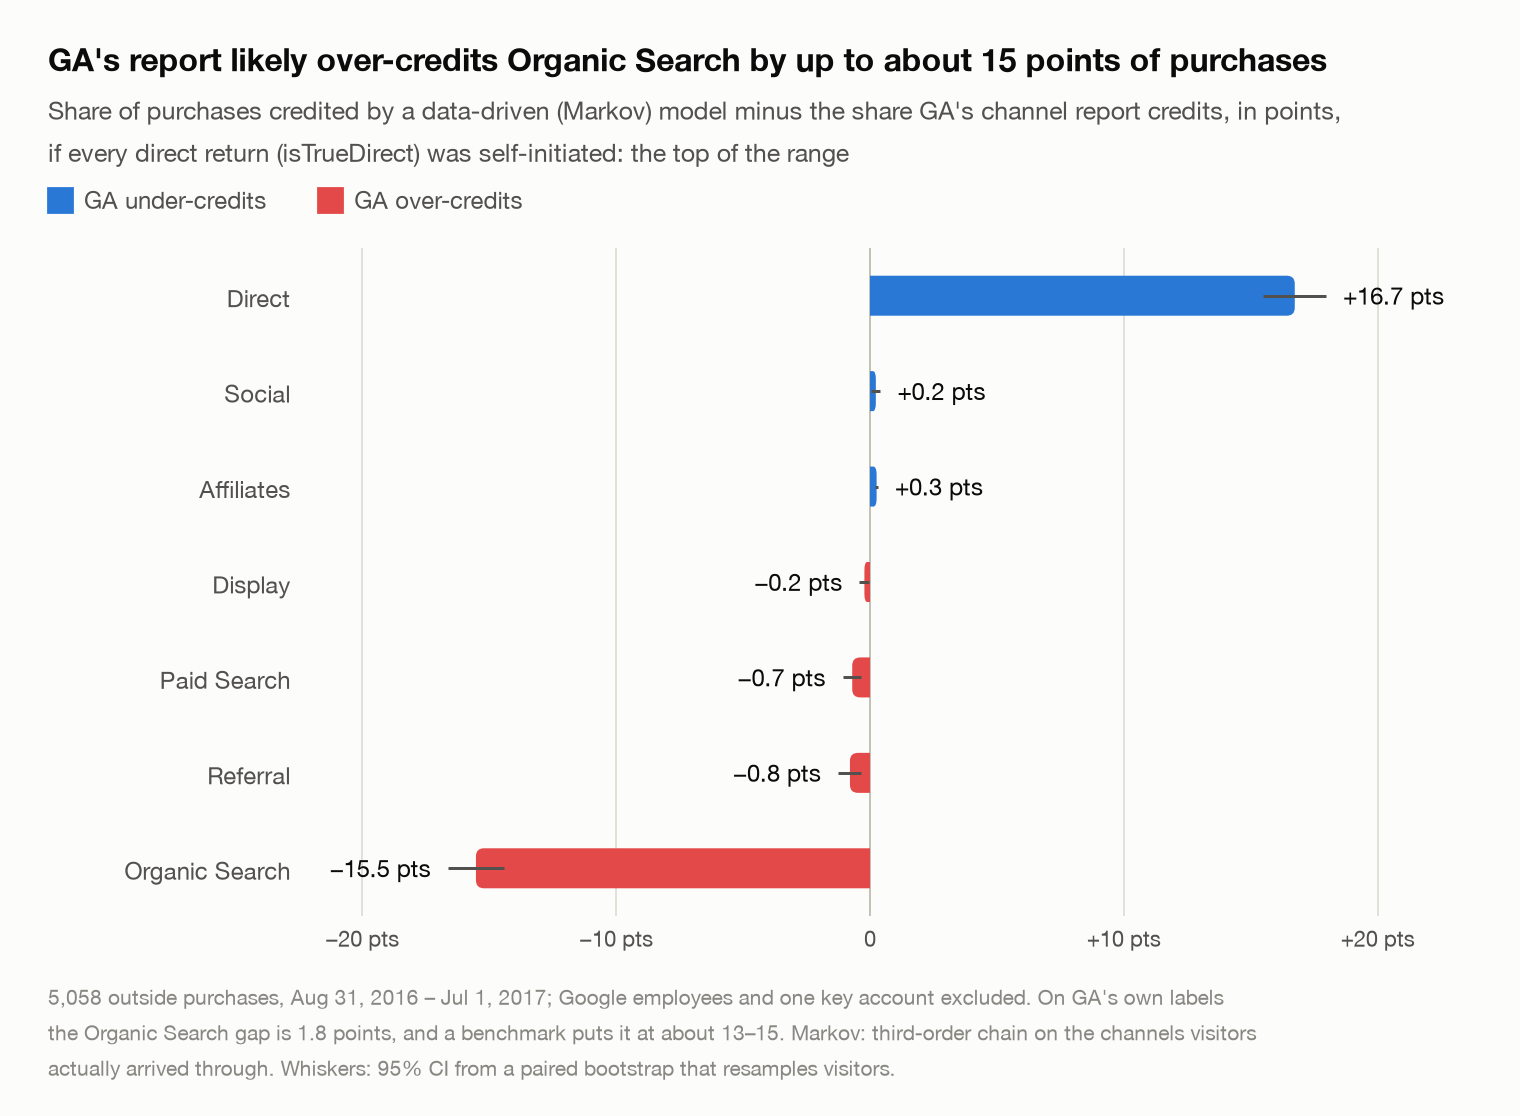

In [15]:
gap = h2.xs("vs GA report", axis=1, level=1)   # the join above drops the level names
chart_order = ["Direct", "Social", "Affiliates", "Display", "Paid Search", "Referral", "Organic Search"]
fig = viz.diverging_ci_chart(
    chart_order, gap.loc[chart_order, "markov_minus_ref_pts"].tolist(),
    gap.loc[chart_order, "ci_low"].tolist(), gap.loc[chart_order, "ci_high"].tolist(),
    title="GA's report likely over-credits Organic Search by up to about 15 points of purchases",
    subtitle=("Share of purchases credited by a data-driven (Markov) model minus the share GA's channel report credits, in points,\n"
              "if every direct return (isTrueDirect) was self-initiated: the top of the range"),
    note=(f"{len(conv):,} outside purchases, Aug 31, 2016 – Jul 1, 2017; Google employees and one key account excluded. On GA's own labels\n"
          "the Organic Search gap is 1.8 points, and a benchmark puts it at about 13–15. Markov: third-order chain on the channels visitors\n"
          "actually arrived through. Whiskers: 95% CI from a paired bootstrap that resamples visitors."),
    pos_label="GA under-credits", neg_label="GA over-credits",
    value_fmt=lambda v: f"{v:+.1f} pts", tick_fmt=lambda t: f"{t:+.0f} pts",
)
viz.show_saved(fig, ROOT / "reports/figures/d1_credit_gap.png")

**H2 depends on which "last click" is meant.**

- **Against true last click (last touch), H2 holds.** The data-driven model gives every journey-starting channel *more* credit: Organic Search +8.2 points, Paid Search +1.2, Display +0.4, Social +0.7, all with intervals above zero.
- **Against GA's actual report, it's reversed.** GA's last-*non-direct* rule hands the credit of later direct returns back to the earlier campaign, which **over-credits** the starters: Organic Search by up to 15.5 points (section 7 shows how much of that is an assumption), Paid Search by 0.7, and Display by 0.2. The channel GA under-credits is **Direct** (+16.7 points): visitors who come back on their own (section 8).

## 7. How much does GA's report over-credit Organic Search?

The 15.5 points above assume every `isTrueDirect` visit was a self-initiated return: typed, bookmarked, or otherwise untracked. But GA also sets `isTrueDirect` when two visits in a row carry identical campaign details, which for Organic Search (`google / organic / (not provided)`) includes a repeat Google search. The export can't tell the two apart, so the answer is a range between two readings of those visits.

In [16]:
readings = {"GA's labels (bottom of the range)": "ga_path",
            "every isTrueDirect visit a self-initiated return (top)": "arrival_path"}
fits = {name: Attribution(journeys, col, order=MARKOV_ORDER) for name, col in readings.items()}
organic = pd.DataFrame({name: fit.shares().loc["Organic Search"] for name, fit in fits.items()}).rename(index=names)
ga_share = shares.loc["Organic Search", "ga_last_click"]
print(f"GA's report gives Organic Search {ga_share:.1%} of purchases. Organic Search share under each model "
      f"(points below GA's report in brackets):")
organic.map(lambda v: f"{v:.1%} ({100 * (v - ga_share):+.1f})".replace("-", "−"))

GA's report gives Organic Search 53.8% of purchases. Organic Search share under each model (points below GA's report in brackets):


,GA's labels (bottom of the range),every isTrueDirect visit a self-initiated return (top)
model,,
GA report,53.8% (+0.0),53.8% (+0.0)
Last touch,53.8% (+0.0),30.0% (−23.7)
First touch,52.3% (−1.5),44.9% (−8.9)
Linear,53.0% (−0.8),35.8% (−17.9)
Position-based,53.0% (−0.8),36.7% (−17.0)
Markov (data-driven),52.0% (−1.8),38.2% (−15.5)


- **Bottom of the range, GA's own labels:** the models give Organic Search 52.0–53.8% of purchases. Markov gives 52.0%, **1.8 points** below GA's report.
- **Top of the range, every `isTrueDirect` visit a self-initiated return:** 30.0–44.9%. Markov gives 38.2%, **15.5 points** below GA's report (95% CI 14.4–16.6, from the visitor-resampling bootstrap in section 5).
- How those visits are read moves Organic Search's share far more than the choice of model.

**The conservative relabel isn't a third reading.** It turns only visits whose source is literally `(direct)` into Direct, and that form depends on the calendar day, not on the visit:

In [17]:
direct_form = ext.source.eq("(direct)")
rows, form_days = [], {}
for ch in ["Organic Search", "Paid Search"]:
    for returning in (True, False):
        m = ext.channel.eq(ch) & ext.is_true_direct.eq(returning)
        daily = direct_form[m].groupby(ext.session_date[m]).mean()
        form_days[ch, returning] = set(daily.index[daily >= 0.9])
        rows.append({"channel": ch, "visits": "isTrueDirect returns" if returning else "fresh clicks", "days": len(daily),
                     "days ≥ 90% '(direct)'": int((daily >= 0.9).sum()),
                     "days between": int(((daily > 0.1) & (daily < 0.9)).sum()), "days ≤ 10%": int((daily <= 0.1).sum())})
artifact_days = form_days["Organic Search", True]
assert all(days == artifact_days for days in form_days.values())
display(pd.DataFrame(rows).set_index(["channel", "visits"]))
conservative = Attribution(journeys, "conservative_path", order=MARKOV_ORDER)
organic_returns = touches[touches.is_true_direct & touches.ga_channel.eq("Organic Search")]
by_month = pd.Series(sorted(artifact_days)).dt.strftime("%Y-%m").value_counts().sort_index()
print("Days by month: " + ", ".join(f"{m} {n}" for m, n in by_month.items()))
print(f"The same {len(artifact_days)} calendar days in every row ({min(artifact_days):%b %d, %Y} – {max(artifact_days):%b %d, %Y}). "
      f"The conservative relabel turns {organic_returns.conservative_channel.eq('Direct').mean():.0%} of Organic Search's isTrueDirect "
      f"visits into Direct, those on these days, and gives Organic Search "
      f"{conservative.shares().loc['Organic Search', 'markov']:.1%} of purchases (Markov).")

days  days ≥ 90% '(direct)'  days between  days ≤ 10%
channel        visits                                                                     
Organic Search isTrueDirect returns   366                    142             0         224
               fresh clicks           366                    142             0         224
Paid Search    isTrueDirect returns   366                    142             0         224
               fresh clicks           366                    142             0         224

Days by month: 2016-09 7, 2016-10 20, 2016-11 29, 2016-12 26, 2017-01 28, 2017-02 11, 2017-04 2, 2017-06 17, 2017-07 1, 2017-08 1
The same 142 calendar days in every row (Sep 23, 2016 – Aug 01, 2017). The conservative relabel turns 45% of Organic Search's isTrueDirect visits into Direct, those on these days, and gives Organic Search 45.6% of purchases (Markov).


On those 142 days (mostly late Sep 2016 – early Feb 2017, and June 2017) the export overwrote source and medium with `(direct)` / `(none)`, for fresh search clicks and return visits alike, and kept the channel. So the conservative relabel is the full relabel applied on 142 calendar days, and its 45.6% for Organic Search is a date-driven mix of the two ends. **It is not independent corroboration**, and it is kept below only as one more rule in the value-per-click range.

### Where in the range? A dial and a benchmark

Let **φ** be the share of `isTrueDirect` visits that were really repeat clicks on the same campaign: those keep GA's label, and the rest become Direct. φ = 0 is the top of the range and φ = 1 is GA's labels. For a benchmark, look at how returning visitors come back after each kind of visit (full year):

In [18]:
seq = ext.sort_values(["full_visitor_id", "visit_start_time"])
previous = seq.groupby("full_visitor_id").channel.shift().rename("previous visit's GA label")
nxt = seq[previous.notna()]
kind = pd.Series(np.select(
    [(nxt.channel.eq("Organic Search") & ~nxt.is_true_direct).to_numpy(bool),
     (nxt.channel.eq("Organic Search") & nxt.is_true_direct).to_numpy(bool),
     nxt.channel.eq("Direct").to_numpy(bool), nxt.is_true_direct.to_numpy(bool)],
    ["fresh Organic click", "isTrueDirect Organic", "Direct (no campaign)", "isTrueDirect, other label"],
    "fresh other click"), index=nxt.index, name="next visit")
bench = pd.crosstab(previous[previous.notna()], kind, normalize="index")
bench["return visits"] = previous.value_counts()
bench = bench.loc[order]
fresh_after_organic, carried_after_organic = bench.loc["Organic Search", ["fresh Organic click", "isTrueDirect Organic"]]
phi_low, phi_high = [(bench.loc[ref, "fresh Organic click"] - fresh_after_organic) / carried_after_organic
                     for ref in ("Direct", "Paid Search")]
display(bench.style.format({**{c: "{:.1%}" for c in bench.columns[:-1]}, "return visits": "{:,}"}))
print(f"Benchmark φ for Organic Search: {phi_low:.0%} (visitors come back through Google as often as after a Direct visit) "
      f"to {phi_high:.0%} (as often as after a Paid Search click)")

next visit,Direct (no campaign),fresh Organic click,fresh other click,isTrueDirect Organic,"isTrueDirect, other label",return visits
previous visit's GA label,,,,,,
Organic Search,0.2%,2.5%,9.3%,87.9%,0.1%,"73,581"
Direct,86.3%,6.9%,6.5%,0.1%,0.2%,"37,232"
Paid Search,0.3%,25.5%,23.6%,0.2%,50.5%,"8,978"
Referral,0.3%,14.3%,14.1%,0.2%,71.1%,"9,516"
Display,0.2%,17.7%,25.3%,0.3%,56.5%,"2,276"
Social,0.1%,4.4%,11.6%,0.0%,83.9%,"14,567"
Affiliates,0.1%,8.0%,16.3%,0.1%,75.6%,"3,807"


Benchmark φ for Organic Search: 5% (visitors come back through Google as often as after a Direct visit) to 26% (as often as after a Paid Search click)


After a Direct visit or a Paid Search click, a return through Google shows up as a fresh Organic click (7% and 26% of next visits). After an Organic visit, the same behavior hides inside `isTrueDirect` Organic. If Organic visitors came back through Google as often as either group, **5–26% of `isTrueDirect` Organic visits would be repeat searches**. This is indicative only: visitors differ by how they last arrived, and the dial applies φ to every channel.

The dial picks visits at random (the same draws for every φ) and averages three seeds:

In [19]:
carried = (touches.is_true_direct & touches.ga_channel.ne("Direct")).to_numpy(bool)
ga_label, arrival = touches.ga_channel.to_numpy(dtype=object), touches.arrival_channel.to_numpy(dtype=object)
journey_of_touch = touches.journey_id.to_numpy()
phis = sorted({0.0, 0.1, 0.25, 0.5, 0.75, 1.0, round(phi_low, 3), round(phi_high, 3)})
dial = {}
for seed in (101, 102, 103):
    u = np.random.default_rng(seed).random(len(touches))
    for phi in phis:
        label = pd.Series(np.where(carried & (u < phi), ga_label, arrival))
        path = journeys.journey_id.map(label.groupby(journey_of_touch, sort=False).agg(" > ".join))
        assert path.notna().all()
        fit = Attribution(journeys.assign(dial_path=path), "dial_path", order=MARKOV_ORDER)
        dial[seed, phi] = fit.shares().loc["Organic Search", "markov"]
dial = pd.Series(dial).unstack(level=0)
dial_table = pd.DataFrame({"Organic Search, Markov": dial.mean(axis=1),
                           "spread over seeds (pts)": 100 * (dial.max(axis=1) - dial.min(axis=1)),
                           "GA's over-credit (pts)": 100 * (ga_share - dial.mean(axis=1))}).rename_axis("φ")
dial_table.index = [f"{phi:.3g}" + (" (benchmark)" if phi in (round(phi_low, 3), round(phi_high, 3)) else "")
                    for phi in dial_table.index]
dial_table.style.format({"Organic Search, Markov": "{:.1%}", "spread over seeds (pts)": "{:.2f}",
                         "GA's over-credit (pts)": "{:.1f}"})

,"Organic Search, Markov",spread over seeds (pts),GA's over-credit (pts)
0,38.2%,0.00,15.5
0.05 (benchmark),38.8%,0.06,15.0
0.1,39.5%,0.09,14.3
0.25,41.0%,0.22,12.7
0.261 (benchmark),41.2%,0.30,12.6
0.5,43.6%,0.47,10.2
0.75,46.6%,0.55,7.1
1,52.0%,0.00,1.8


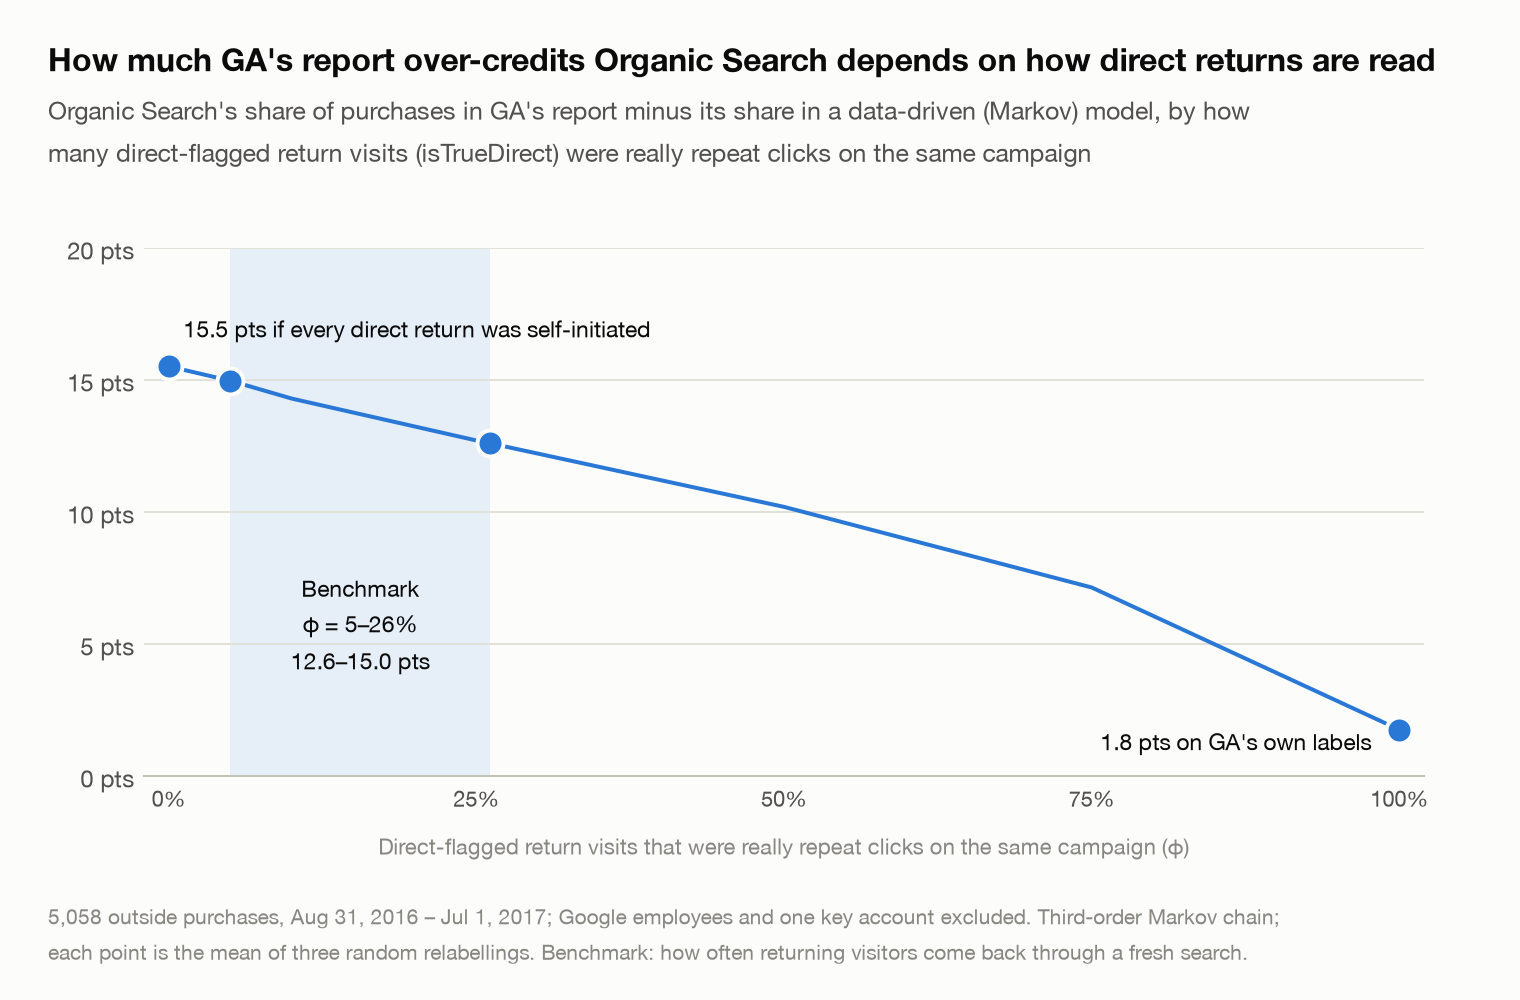

In [20]:
over_credit = 100 * (ga_share - dial.mean(axis=1))
band = np.interp([phi_high, phi_low], over_credit.index, over_credit)
fig = viz.assumption_line_chart(
    over_credit.index.tolist(), over_credit.tolist(), (phi_low, phi_high),
    title="How much GA's report over-credits Organic Search depends on how direct returns are read",
    subtitle=("Organic Search's share of purchases in GA's report minus its share in a data-driven (Markov) model, by how\n"
              "many direct-flagged return visits (isTrueDirect) were really repeat clicks on the same campaign"),
    note=(f"{len(conv):,} outside purchases, Aug 31, 2016 – Jul 1, 2017; Google employees and one key account excluded. Third-order Markov chain;\n"
          "each point is the mean of three random relabellings. Benchmark: how often returning visitors come back through a fresh search."),
    x_label="Direct-flagged return visits that were really repeat clicks on the same campaign (φ)",
    band_label=f"Benchmark\nφ = {100 * phi_low:.0f}–{100 * phi_high:.0f}%\n{band[0]:.1f}–{band[1]:.1f} pts",
    end_labels=(f"{over_credit.iloc[0]:.1f} pts if every direct return was self-initiated",
                f"{over_credit.iloc[-1]:.1f} pts on GA's own labels"))
viz.show_saved(fig, ROOT / "reports/figures/d1_organic_range.png")

At the benchmark, GA's report over-credits Organic Search by **about 13–15 points** of purchases, close to the top of the range. That is why the headline reads **"likely up to about 15 points"**: 15.5 if every `isTrueDirect` visit was a self-initiated return, 1.8 if every one was a repeat click on the same campaign.

### Where the points come from

GA credits Organic Search with 2,719 purchases. For **355 of them the modeled journey contains no Organic visit at all** (354 are all-Direct paths). Each is traced back through the visitor's whole history in the data:

In [21]:
no_organic = conv[conv.ga_last_channel.eq("Organic Search") & ~conv.arrival_path.str.contains("Organic Search", regex=False)]
print(f"GA credits Organic Search with {int(conv.ga_last_channel.eq('Organic Search').sum()):,} purchases. {len(no_organic)} of them have "
      f"no Organic visit in the journey ({int(no_organic.arrival_path.str.fullmatch('Direct( > Direct)*').sum())} all-Direct).")
bought = touches.loc[touches.purchased & touches.journey_id.isin(no_organic.journey_id),
                     ["journey_id", "full_visitor_id", "visit_start_time"]].rename(columns={"visit_start_time": "bought_at"})
earlier = bought.merge(ext[["full_visitor_id", "visit_start_time", "channel", "is_true_direct", "purchased"]], on="full_visitor_id")
earlier = earlier[earlier.visit_start_time < earlier.bought_at]
last_click = earlier[earlier.channel.eq("Organic Search") & ~earlier.is_true_direct].groupby("journey_id").visit_start_time.max()
trace = bought.set_index("journey_id").assign(earlier_visits=earlier.groupby("journey_id").size(), organic_click=last_click)
trace["days_since_click"] = ((trace.bought_at - trace.organic_click) / 86400).astype(float)
restart = "Organic click within 30 days, but an earlier purchase restarted the journey"
trace["reason"] = np.select(
    [trace.earlier_visits.isna().to_numpy(), trace.organic_click.isna().to_numpy(), (trace.days_since_click > 30).to_numpy()],
    ["No earlier visit in the data", "Earlier visits, but no Organic click in the data (GA's label predates it)",
     "Organic click more than 30 days before the purchase (outside the lookback)"], restart)
# a click within 30 days is missing from the journey only if a purchase came in between
between = earlier.join(last_click.rename("organic_click"), on="journey_id").dropna(subset=["organic_click"])
between = between[between.purchased & (between.visit_start_time >= between.organic_click)]
assert set(trace.index[trace.reason == restart]) <= set(between.journey_id)
reasons = trace.reason.value_counts().rename("purchases").to_frame()
reasons["points of purchase share"] = 100 * reasons.purchases / len(conv)
reasons.loc["Total"] = reasons.sum()
display(reasons.style.format({"purchases": "{:,.0f}", "points of purchase share": "{:.2f}"}))
late = trace[trace.days_since_click > 30].days_since_click
print(f"Organic click more than 30 days before: median {late.median():.0f} days, longest {late.max():.0f} "
      f"(GA's campaign timeout is 6 months). {trace.full_visitor_id.nunique()} visitors.")

GA credits Organic Search with 2,719 purchases. 355 of them have no Organic visit in the journey (354 all-Direct).


,purchases,points of purchase share
reason,,
Organic click more than 30 days before the purchase (outside the lookback),175,3.46
"Organic click within 30 days, but an earlier purchase restarted the journey",107,2.12
"Earlier visits, but no Organic click in the data (GA's label predates it)",43,0.85
No earlier visit in the data,30,0.59
Total,355,7.02


Organic click more than 30 days before: median 55 days, longest 181 (GA's campaign timeout is 6 months). 289 visitors.


Markov credit isn't additive across journeys, so the Markov-consistent version relabels groups of journeys from GA's labels to arrival labels and averages each group's effect over every order of relabeling (Shapley values, 16 fits):

In [22]:
has_organic = journeys.arrival_path.str.contains("Organic Search", regex=False)
ga_organic = journeys.ga_last_channel.eq("Organic Search")
groups = {"purchases GA gives Organic Search, no Organic visit in the journey": journeys.converted & ga_organic & ~has_organic,
          "purchases GA gives Organic Search, with an Organic visit": journeys.converted & ga_organic & has_organic,
          "purchases GA gives another channel": journeys.converted & ~ga_organic,
          "journeys without a purchase": ~journeys.converted}


def organic_share(relabelled):
    use = np.zeros(len(journeys), bool)
    for g in relabelled:
        use |= groups[g].to_numpy(bool)
    mixed = journeys.assign(mixed_path=np.where(use, journeys.arrival_path, journeys.ga_path))
    return 100 * Attribution(mixed, "mixed_path", order=MARKOV_ORDER).shares().loc["Organic Search", "markov"]


fitted = {frozenset(s): organic_share(s) for k in range(len(groups) + 1) for s in itertools.combinations(groups, k)}
steps = dict.fromkeys(groups, 0.0)
for perm in itertools.permutations(groups):
    for i, g in enumerate(perm):
        steps[g] += (fitted[frozenset(perm[:i + 1])] - fitted[frozenset(perm[:i])]) / math.factorial(len(groups))
waterfall = pd.Series({"GA's report": 100 * ga_share,
                       "model: GA's report → Markov on GA's labels": fitted[frozenset()] - 100 * ga_share,
                       **{f"relabel {g}": v for g, v in steps.items()},
                       "= Markov, every isTrueDirect visit a self-initiated return": fitted[frozenset(groups)]})
waterfall.rename("Organic Search share of purchases (pts)").to_frame().style.format("{:+.2f}")

,Organic Search share of purchases (pts)
GA's report,+53.76
model: GA's report → Markov on GA's labels,-1.75
"relabel purchases GA gives Organic Search, no Organic visit in the journey",-5.85
"relabel purchases GA gives Organic Search, with an Organic visit",-7.49
relabel purchases GA gives another channel,-1.21
relabel journeys without a purchase,+0.79
"= Markov, every isTrueDirect visit a self-initiated return",+38.24


- **About 7 of the 15.5 points come from the 355 purchases whose journey has no Organic visit** (7.0 by count; 5.9 in the Markov model's own accounting). For 282 of them an Organic click did bring the visitor within GA's 6-month campaign window, just more than 30 days before the purchase (3.5 points) or before an earlier purchase that restarted the journey (2.1). For the other 73 the click isn't in the data (1.4). **Whether Organic Search deserves that credit is a journey-window choice, not a finding.**
- **Most of the rest (7.5 points) is return visits inside journeys that do contain an Organic click**, which is exactly what the φ dial is about. Purchases GA gives other channels add 1.2, the model itself 1.8, and relabeling journeys without a purchase gives 0.8 back.

In [23]:
removal = att.credit_table()[("markov", "removal_effect")]
print(f"Organic Search starts {shares.loc['Organic Search', 'first_touch']:.0%} of buying journeys (first touch), and removing it "
      f"from every path would lose {removal['Organic Search']:.0%} of purchases in the Markov model.")

Organic Search starts 45% of buying journeys (first touch), and removing it from every path would lose 49% of purchases in the Markov model.


**Organic Search, in one line:** GA's report likely over-credits Organic Search by **up to about 15 points** of purchases: 15.5 (95% CI 14.4–16.6) if every `isTrueDirect` visit is a self-initiated return, about 13–15 at the benchmark, 1.8 on GA's own labels. About 7 points depend on the journey window (30-day lookback, restart after a purchase) or on clicks not in the data. The direction holds under every reading but the size rests on an assumption the data can't check, so **confidence is moderate, not high**. Organic Search still starts 45% of buying journeys, and removing it would lose about half of purchases in the model.

## 8. Returning visitors

Direct, in the arrival paths, mixes two groups: people **returning on their own**, and **first-ever visits that arrived direct** (a typed URL, a bookmark from another browser, or an untracked link). Splitting Direct by visit number:

In [24]:
visit_number = touches[["full_visitor_id", "visit_start_time"]].merge(
    sessions[["full_visitor_id", "visit_start_time", "visit_number"]], how="left", validate="one_to_one").visit_number
first_visit = visit_number.eq(1).to_numpy(bool)
split_label = touches.arrival_channel.where(touches.arrival_channel.ne("Direct"),
                                            np.where(first_visit, "Direct (first visit)", "Direct (returning)"))
journeys["split_path"] = journeys.journey_id.map(split_label.groupby(journey_of_touch, sort=False).agg(" > ".join))
split = Attribution(journeys, "split_path", order=MARKOV_ORDER)
split_shares, split_revenue = split.shares(), split.shares(measure="revenue")
parts = pd.DataFrame({"Markov, purchases": split_shares["markov"], "Markov, capped revenue": split_revenue["markov"],
                      "Last touch": split_shares["last_touch"], "First touch": split_shares["first_touch"],
                      "Linear": split_shares["linear"]})
parts = parts.loc[["Direct (returning)", "Direct (first visit)", "Organic Search", "Paid Search", "Referral", "Display",
                   "Social", "Affiliates"]]
parts.loc["Direct, not split (for reference)"] = [shares.loc["Direct", "markov"], att.shares(measure="revenue").loc["Direct", "markov"],
                                                  shares.loc["Direct", "last_touch"], shares.loc["Direct", "first_touch"],
                                                  shares.loc["Direct", "linear"]]
display(parts.style.format("{:.1%}"))
direct = touches.arrival_channel.eq("Direct").to_numpy(bool)
print(f"Direct visits: {direct.sum():,}, of which first-ever visits {(direct & first_visit).sum():,} ({(direct & first_visit).sum() / direct.sum():.0%}). "
      f"Purchases on a Direct visit: {(direct & touches.purchased.to_numpy(bool)).sum():,}, on a first-ever visit "
      f"{(direct & first_visit & touches.purchased.to_numpy(bool)).sum():,}; {int((journeys.converted & journeys.split_path.eq('Direct (first visit)')).sum()):,} "
      f"purchasing journeys are a single first visit.")
print(f"Sum of Markov removal effects (what every Markov share is divided by): {removal.sum():.3f} with Direct as one channel, "
      f"{split.credit_table()[('markov', 'removal_effect')].sum():.3f} with Direct split in two.")

,"Markov, purchases","Markov, capped revenue",Last touch,First touch,Linear
Direct (returning),34.0%,44.3%,45.5%,18.3%,34.7%
Direct (first visit),18.9%,20.2%,15.4%,25.6%,19.5%
Organic Search,35.6%,24.8%,30.0%,44.9%,35.8%
Paid Search,6.3%,4.8%,5.6%,7.3%,6.4%
Referral,2.0%,2.3%,1.4%,1.2%,1.3%
Display,1.3%,1.5%,1.0%,1.4%,1.2%
Social,1.6%,1.6%,1.0%,1.2%,1.1%
Affiliates,0.3%,0.4%,0.0%,0.1%,0.0%
"Direct, not split (for reference)",49.3%,61.0%,60.9%,43.9%,54.2%


Direct visits: 196,422, of which first-ever visits 87,166 (44%). Purchases on a Direct visit: 3,082, on a first-ever visit 779; 776 purchasing journeys are a single first visit.
Sum of Markov removal effects (what every Markov share is divided by): 1.286 with Direct as one channel, 1.388 with Direct split in two.


- **Visitors returning directly: 34.0% of purchases and 44.3% of capped revenue.** When they first came from a campaign, GA's report credits that campaign; the rest it already labels Direct.
- **First-ever visits that arrived direct: 18.9% and 20.2%.** They are 44% of Direct visits, and 776 purchases are a single first visit.
- **Quote the two parts from this split model, but keep Organic Search's headline share from the unsplit model**: splitting Direct into two states raises the sum of removal effects that every Markov share is divided by (1.29 → 1.39), which lowers every other channel's share (Organic Search 38.2% → 35.6%) without changing its own removal effect.
- Both parts assume every `isTrueDirect` visit was a self-initiated return, and shrink if some were repeat campaign clicks (section 7). `visit_number` counts per cookie, so a "first visit" can be a known customer on a new device.

## 9. Sensitivity

In [25]:
revenue_shares = att.shares(measure="revenue")
sens = pd.DataFrame({
    "GA report (purchases)": shares["ga_last_click"],
    "Markov (purchases)": shares["markov"],
    "GA report (capped revenue)": revenue_shares["ga_last_click"],
    "Markov (capped revenue)": revenue_shares["markov"],
}).loc[order]
display(sens.style.format("{:.1%}"))
presence = pd.concat({"purchases": credit_vs_presence(att), "capped revenue": credit_vs_presence(att, measure="revenue")},
                     axis=1).loc[order]
print("Markov credit vs the purchasing journeys that contain each channel:")
presence.style.format({("purchases", "credited"): "{:,.1f}", ("purchases", "presence"): "{:,.0f}",
                       ("capped revenue", "credited"): "${:,.0f}", ("capped revenue", "presence"): "${:,.0f}"})

,GA report (purchases),Markov (purchases),GA report (capped revenue),Markov (capped revenue)
Organic Search,53.8%,38.2%,38.9%,27.4%
Direct,32.6%,49.3%,47.8%,61.0%
Paid Search,7.5%,6.7%,5.9%,5.3%
Referral,3.0%,2.2%,4.6%,2.6%
Display,1.6%,1.4%,1.9%,1.6%
Social,1.5%,1.8%,0.9%,1.7%
Affiliates,0.1%,0.3%,0.0%,0.4%


Markov credit vs the purchasing journeys that contain each channel:


- **Revenue credit** (Markov with each step into a purchase carrying the average order value that follows it) tilts further toward Direct, 61% of capped revenue, because the largest orders come from people returning on their own.
- **Presence check.** No rule confined to a channel's own journeys can credit it with more purchases than the purchasing journeys that contain it. The third-order Markov chain does, for **Social (88.6 purchases from 75 journeys) and Affiliates (16.1 from 4)**, and for their revenue: after three Direct steps the chain forgets where a visitor came from, so removing either channel removes purchases its journeys never produced. **Their Markov values are not used in any headline**; both bring almost no purchases under every rule.

## 10. What is one paid click worth?

For budgeting, the question is revenue per **visit the channel actually brought**, which for paid channels is revenue per ad click. The denominator is the same for every rule: arrival visits, not GA's relabeled session counts. This is **attributed value per click**: it assumes every credited sale needed the click, so it is a ceiling on what a click is worth, not profit.

In [26]:
clicks = touches.arrival_channel.value_counts()
credited = att.credit_table().xs("revenue", axis=1, level="measure")[MODELS].copy()
credited["markov_conservative"] = conservative.credit_table()[("markov", "revenue")]
paid = ["Paid Search", "Display", "Affiliates"]
rule_names = {**names, "markov_conservative": "Markov, conservative relabel"}
per_click = credited.loc[paid].div(clicks.loc[paid], axis=0).T.rename(index=rule_names)
display(per_click.style.format("${:.2f}"))
print("Clicks (arrival visits): " + ", ".join(f"{c} {clicks[c]:,}" for c in paid))

,Paid Search,Display,Affiliates
model,,,
GA report,$2.21,$3.87,$0.01
Last touch,$1.56,$2.89,$0.00
First touch,$2.08,$2.96,$0.01
Linear,$1.78,$2.84,$0.00
Position-based,$1.81,$2.90,$0.00
Markov (data-driven),$2.01,$3.28,$0.27
"Markov, conservative relabel",$2.43,$3.80,$0.07


Clicks (arrival visits): Paid Search 17,575, Display 3,282, Affiliates 10,549


In [27]:
# The same rules with the key account kept in. src/journeys.py leaves key accounts out, so its visitor id is masked first.
from src.journeys import journeys as build_journeys, touches as build_touches
t_key = build_touches(sessions.assign(
    full_visitor_id=sessions.full_visitor_id.mask(is_key_account(sessions.full_visitor_id), KEY_ACCOUNT)))
j_key = build_journeys(t_key, revenue_cap_usd=CAP)
assert j_key.full_visitor_id.ne(KEY_ACCOUNT).sum() == len(journeys), "only the key account's journeys should be added"
credited_key = Attribution(j_key, "arrival_path", order=MARKOV_ORDER).credit_table() \
    .xs("revenue", axis=1, level="measure")[MODELS].copy()
credited_key["markov_conservative"] = Attribution(j_key, "conservative_path", order=MARKOV_ORDER).credit_table()[("markov", "revenue")]
clicks_key = t_key.arrival_channel.value_counts()
per_click_key = credited_key.loc[paid].div(clicks_key.loc[paid], axis=0).T.rename(index=rule_names)
share_key = (credited_key.loc[paid] / credited_key.loc[paid].sum()).T.rename(index=rule_names)
ga_display_with_key = per_click_key.loc["GA report", "Display"]
print(f"With the key account kept in: {len(j_key):,} journeys, {int(j_key.converted.sum()):,} with a purchase, "
      f"{clicks_key['Display']:,} Display clicks.")
print("Display's attributed value per click with the account: "
      + ", ".join(f"{r} ${v:.2f} ({v:.3f})" for r, v in per_click_key.Display.items())
      + f". Range ${per_click_key.Display.min():.2f}–${per_click_key.Display.max():.2f}.")
print(f"Display's share of paid credit under GA's report: {share_key.loc['GA report', 'Display']:.0%} "
      f"({share_key.loc['GA report', 'Display']:.1%}) with the account, "
      f"{credited.loc['Display', 'ga_last_click'] / credited.loc[paid, 'ga_last_click'].sum():.0%} without it.")

With the key account kept in: 580,775 journeys, 5,074 with a purchase, 3,283 Display clicks.
Display's attributed value per click with the account: GA report $9.08 (9.081), Last touch $2.89 (2.893), First touch $2.96 (2.959), Linear $2.85 (2.849), Position-based $2.90 (2.901), Markov (data-driven) $3.31 (3.307), Markov, conservative relabel $8.15 (8.154). Range $2.85–$9.08.
Display's share of paid credit under GA's report: 43% (43.3%) with the account, 25% without it.


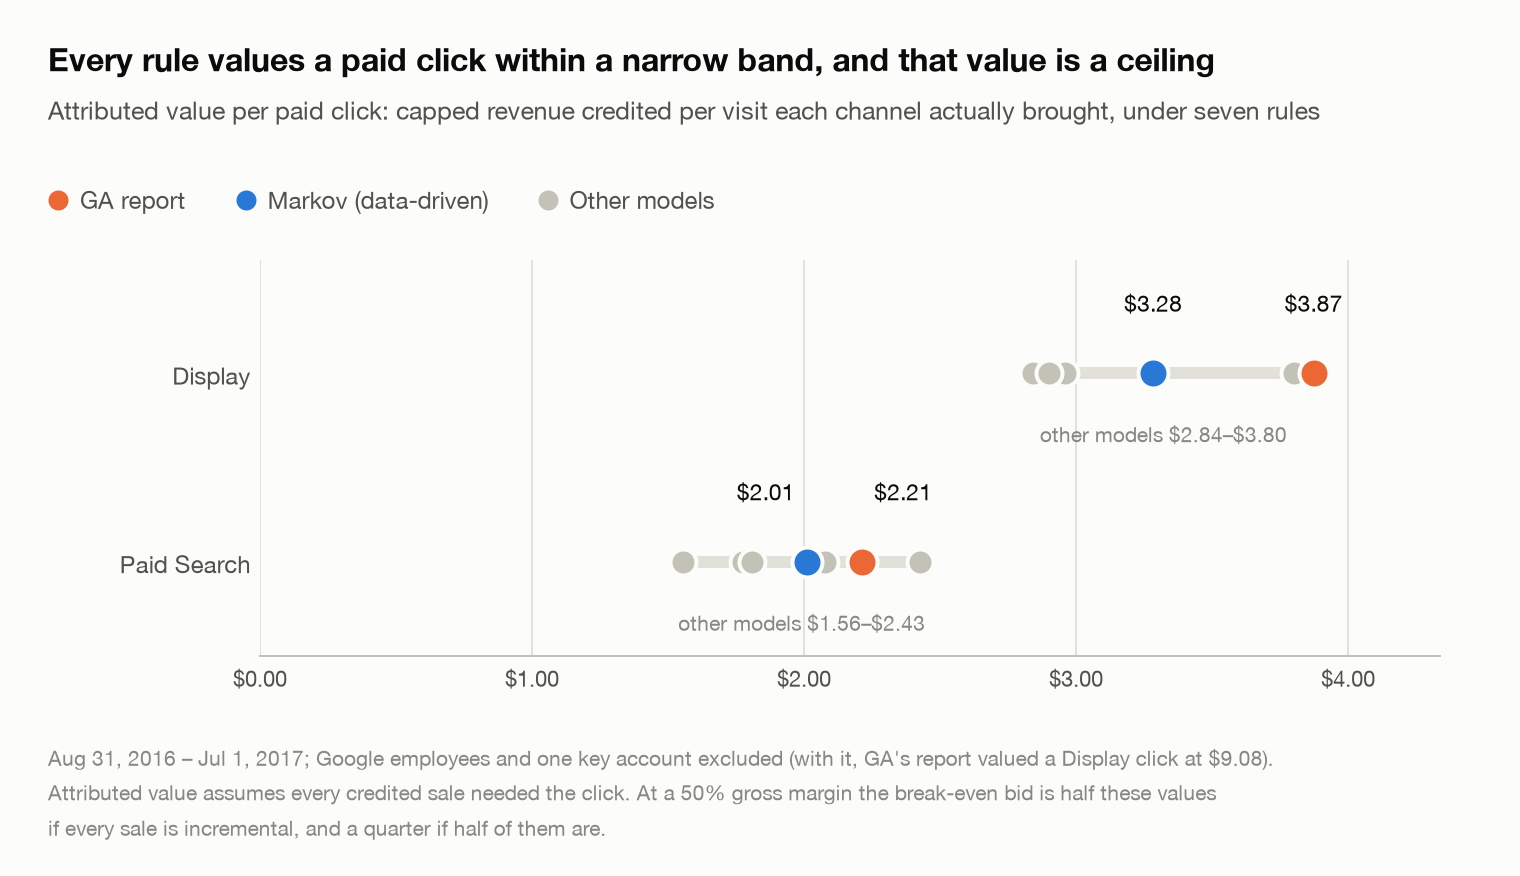

In [28]:
points = {g: per_click[g].to_dict() for g in ["Display", "Paid Search"]}
fig = viz.value_strip_chart(
    ["Display", "Paid Search"], points, {"GA report": "#eb6834", "Markov (data-driven)": viz.SERIES_1},
    title="Every rule values a paid click within a narrow band, and that value is a ceiling",
    subtitle="Attributed value per paid click: capped revenue credited per visit each channel actually brought, under seven rules",
    note=(f"Aug 31, 2016 – Jul 1, 2017; Google employees and one key account excluded (with it, GA's report valued a Display click at "
          f"${ga_display_with_key:.2f}).\n"
          "Attributed value assumes every credited sale needed the click. At a 50% gross margin the break-even bid is half these values\n"
          "if every sale is incremental, and a quarter if half of them are."),
)
viz.show_saved(fig, ROOT / "reports/figures/d1_value_per_click.png")

### Paid Search: a ceiling, not a target

Bid cap = attributed value per click × 50% gross margin × the share of attributed sales the ads actually caused (incrementality, unknown here):

In [29]:
MARGIN = 0.5
value = per_click["Paid Search"]
caps = pd.DataFrame({"attributed value per click": value,
                     **{f"bid cap, {share:.0%} incremental": value * MARGIN * share for share in (1.0, 0.5, 0.25)}})
display(caps.style.format("${:.2f}"))

journey_paths = conv.arrival_path.str.split(" > ")
with_paid = journey_paths.map(lambda p: "Paid Search" in p)
only_paid = journey_paths.map(lambda p: set(p) == {"Paid Search"})
ps_clicks = touches[touches.arrival_channel == "Paid Search"].assign(visit_number=visit_number)
ps_buys = ps_clicks[ps_clicks.purchased]
returning = ps_buys.visit_number > 1
print(f"Buying journeys that touch Paid Search: {with_paid.sum()}; Paid Search is the only channel in {only_paid.sum()} "
      f"({only_paid.sum() / with_paid.sum():.0%}).")
print(f"Purchases made on a Paid Search click: {len(ps_buys)}; by returning visitors: {returning.sum()} ({returning.mean():.0%}), "
      f"holding {ps_buys[returning].revenue_usd.sum() / ps_buys.revenue_usd.sum():.0%} of their revenue. Returning visitors make "
      f"{(ps_clicks.visit_number > 1).mean():.0%} of Paid Search clicks.")

,attributed value per click,"bid cap, 100% incremental","bid cap, 50% incremental","bid cap, 25% incremental"
model,,,,
GA report,$2.21,$1.11,$0.55,$0.28
Last touch,$1.56,$0.78,$0.39,$0.19
First touch,$2.08,$1.04,$0.52,$0.26
Linear,$1.78,$0.89,$0.44,$0.22
Position-based,$1.81,$0.90,$0.45,$0.23
Markov (data-driven),$2.01,$1.00,$0.50,$0.25
"Markov, conservative relabel",$2.43,$1.21,$0.61,$0.30


Buying journeys that touch Paid Search: 437; Paid Search is the only channel in 231 (53%).
Purchases made on a Paid Search click: 282; by returning visitors: 104 (37%), holding 52% of their revenue. Returning visitors make 23% of Paid Search clicks.


I also check three numbers the write-up quotes here: the purchases the two Markov rules credit to Paid Search, what merging visits split at midnight would change, and what later purchases by the same buyers would add.

In [30]:
ps_markov = pd.Series({rule_names["markov"]: att.credit_table().loc["Paid Search", ("markov", "conversions")],
                       rule_names["markov_conservative"]: conservative.credit_table().loc["Paid Search", ("markov", "conversions")]})
print("Purchases credited to Paid Search: " + ", ".join(f"{r} {v:.0f} ({v:.2f})" for r, v in ps_markov.items())
      + f". Buying journeys where Paid Search is the only channel: {only_paid.sum()} of {with_paid.sum()}.")

Purchases credited to Paid Search: Markov (data-driven) 341 (341.38), Markov, conservative relabel 385 (385.47). Buying journeys where Paid Search is the only channel: 231 of 437.


In [31]:
# A visit split at midnight keeps one visit_id, so its two halves are two touches here
visit_id = touches[["full_visitor_id", "visit_start_time"]].merge(
    sessions[["full_visitor_id", "visit_start_time", "visit_id"]], how="left", validate="one_to_one").visit_id
with_id = touches.assign(visit_id=visit_id.to_numpy())
halves = with_id.groupby(["full_visitor_id", "visit_id"]).size()
merged_clicks = with_id.drop_duplicates(["full_visitor_id", "visit_id", "arrival_channel"]).arrival_channel.value_counts()
extra_ps = clicks["Paid Search"] / merged_clicks["Paid Search"] - 1
extra_paid = clicks.loc[paid].sum() / merged_clicks.loc[paid].sum() - 1
ceiling, ceiling_merged = [(credited.loc["Paid Search"] / n * MARGIN).max()
                           for n in (clicks["Paid Search"], merged_clicks["Paid Search"])]
print(f"Visits split at midnight: {(halves == 2).sum():,} pairs among the journey touches (most rows per visit: {halves.max()}).")
print("Clicks counting both halves vs merged: " + ", ".join(f"{c} {clicks[c]:,} vs {merged_clicks[c]:,}" for c in paid)
      + f". Both halves add {extra_ps:.1%} ({extra_ps:.2%}) to Paid Search clicks, {extra_paid:.1%} ({extra_paid:.2%}) to all paid clicks.")
print(f"Paid Search ceiling (highest bid cap at 100% incremental): ${ceiling:.2f} ({ceiling:.4f}) counting both halves, "
      f"${ceiling_merged:.2f} ({ceiling_merged:.4f}) with them merged.")

Visits split at midnight: 658 pairs among the journey touches (most rows per visit: 2).
Clicks counting both halves vs merged: Paid Search 17,575 vs 17,545, Display 3,282 vs 3,280, Affiliates 10,549 vs 10,529. Both halves add 0.2% (0.17%) to Paid Search clicks, 0.2% (0.17%) to all paid clicks.
Paid Search ceiling (highest bid cap at 100% incremental): $1.21 (1.2134) counting both halves, $1.22 (1.2155) with them merged.


In [32]:
# Buyers who bought in the journey that began with their first visit, a Paid Search click, and their later buying journeys
first_click = ps_clicks[ps_clicks.visit_number.eq(1)]
own = conv[conv.journey_id.isin(first_click.journey_id)]
later = conv[conv.full_visitor_id.isin(own.full_visitor_id) & ~conv.journey_id.isin(own.journey_id)]
uncredited = later[~later.arrival_path.str.contains("Paid Search", regex=False)]   # no Paid Search click in the journey
per_click_all, per_click_uncredited = [d.revenue_capped_usd.sum() / len(ps_clicks) for d in (later, uncredited)]
print(f"Buyers whose first visit was a Paid Search click and who bought in that journey: {own.full_visitor_id.nunique()}. "
      f"Their later purchases in the period: {len(later)}, ${later.revenue_capped_usd.sum():,.0f} capped, "
      f"${per_click_all:.2f} per Paid Search click ({per_click_all:.3f}).")
print(f"Of those, in later journeys with no Paid Search click: {len(uncredited)}, "
      f"${uncredited.revenue_capped_usd.sum():,.0f} capped, ${per_click_uncredited:.2f} per click ({per_click_uncredited:.3f}), "
      f"over all {len(ps_clicks):,} Paid Search clicks.")

Buyers whose first visit was a Paid Search click and who bought in that journey: 319. Their later purchases in the period: 25, $2,846 capped, $0.16 per Paid Search click (0.162).
Of those, in later journeys with no Paid Search click: 16, $1,179 capped, $0.07 per click (0.067), over all 17,575 Paid Search clicks.


**Brand or non-brand?** The keyword behind each Paid Search click comes from a separate extract that the next cell queries ([`sql/prepare/p09_paid_search_keywords.sql`](../sql/prepare/p09_paid_search_keywords.sql); about 0.25 GB scanned on the first run), joined on visitor and visit start. Keywords are sorted into five classes (`search_keyword_class` in [`src/attribution.py`](../src/attribution.py)): brand keywords naming the store or its brands, other readable keywords, targeting placeholders such as `(automatic matching)`, obfuscated IDs, and missing.

In [33]:
keywords = bq.query("prepare/p09_paid_search_keywords.sql", cache="p09_paid_search_keywords")
fresh = keywords.loc[~keywords.is_true_direct, ["full_visitor_id", "visit_start_time", "keyword", "campaign", "landing_page", "source"]]
print(f"Keyword extract: {len(keywords):,} Paid Search sessions (all visitors, full year), {len(fresh):,} of them fresh clicks. "
      f"{fresh.keyword.isna().sum():,} fresh clicks have no keyword, {(fresh.keyword.isna() & fresh.source.eq('(direct)')).sum():,} "
      f"of them with the blanked '(direct)' source.")
fresh = fresh.drop(columns="source")
ps_kw = ps_clicks.merge(fresh, on=["full_visitor_id", "visit_start_time"], how="left", validate="one_to_one", indicator=True)
assert ps_kw._merge.eq("both").all(), "every Paid Search click should have a row in the keyword extract"
ps_kw["keyword_class"] = ps_kw.keyword.map(search_keyword_class)
ps_kw["revenue_capped"] = ps_kw.revenue_usd.clip(upper=CAP)
ps_kw["blanked_day"] = ps_kw.session_date.isin(artifact_days)
by_class = ps_kw.groupby("keyword_class").agg(
    clicks=("purchased", "size"), purchases=("purchased", "sum"), capped_revenue=("revenue_capped", "sum"),
    home_page_landings=("landing_page", lambda p: p.eq("/home").mean()),
    on_blanked_days=("blanked_day", "mean")).reindex(KEYWORD_CLASSES)
by_class["conversion_rate"] = by_class.purchases / by_class.clicks
by_class["share_of_purchases"] = by_class.purchases / by_class.purchases.sum()
display(by_class.style.format({"clicks": "{:,}", "purchases": "{:,}", "capped_revenue": "${:,.0f}",
                               "home_page_landings": "{:.0%}", "on_blanked_days": "{:.0%}", "conversion_rate": "{:.2%}",
                               "share_of_purchases": "{:.0%}"}))
readable = by_class.loc[["Brand or store name", "Readable, no brand"], "purchases"]
unreadable = by_class.loc[["Obfuscated ID", "Missing"], "purchases"].sum()
print(f"Purchases with a readable keyword: {readable.sum()}, of which from brand or store-name searches: {readable.iloc[0]}. "
      f"Without a readable keyword: {unreadable} of {len(ps_buys)} ({unreadable / len(ps_buys):.0%}).")
top = ps_kw[ps_kw.purchased & ps_kw.keyword_class.eq("Brand or store name")].keyword.value_counts()
print("Brand-search purchases by keyword: " + ", ".join(f"'{k}' {n}" for k, n in top.items()))
kept = ps_kw[~ps_kw.blanked_day & ps_kw.purchased].keyword_class.value_counts()
print(f"On the days the export kept keywords: {kept.sum()} purchases, {kept.get('Brand or store name', 0)} from brand or store-name "
      f"searches ({kept.get('Brand or store name', 0) / kept.sum():.0%}) and {kept.get('Obfuscated ID', 0)} with an obfuscated ID.")
print("Campaigns behind the obfuscated IDs: " + ", ".join(ps_kw.loc[ps_kw.keyword_class.eq("Obfuscated ID"), "campaign"].unique()))

Keyword extract: 25,326 Paid Search sessions (all visitors, full year), 20,537 of them fresh clicks. 10,223 fresh clicks have no keyword, 10,151 of them with the blanked '(direct)' source.


,clicks,purchases,capped_revenue,home_page_landings,on_blanked_days,conversion_rate,share_of_purchases
keyword_class,,,,,,,
Brand or store name,"3,897",65,"$9,578",99%,0%,1.67%,23%
"Readable, no brand",3,0,$0,33%,0%,0.00%,0%
Targeting or automatic,705,0,$0,98%,0%,0.00%,0%
Obfuscated ID,"3,043",55,"$4,140",69%,0%,1.81%,20%
Missing,"9,927",162,"$13,620",90%,99%,1.63%,57%


Purchases with a readable keyword: 65, of which from brand or store-name searches: 65. Without a readable keyword: 217 of 282 (77%).
Brand-search purchases by keyword: 'Google Merchandise' 29, 'google merchandise store' 24, '+Google +Merchandise' 4, '+Google +Swag' 2, '+google +merchandise +store' 2, '+google +stores' 1, 'google store merchandise' 1, 'google stickers' 1, '+google +merch' 1
On the days the export kept keywords: 120 purchases, 65 from brand or store-name searches (54%) and 55 with an obfuscated ID.
Campaigns behind the obfuscated IDs: AW - Dynamic Search Ads Whole Site


- **Every Paid Search purchase with a readable keyword was on a brand keyword** (one naming the store or its brands): 65 of 65, and 62 of them name the store or its merchandise ("Google Merchandise" 29, "google merchandise store" 24). GA records the advertiser's bidded keyword, not the user's query, and this export has no match type, so "brand search" is inferred from the keyword. These are **the clicks least likely to be incremental**, since many of those buyers would likely have found the organic result instead.
- **But 77% of Paid Search purchases have no readable keyword** (217 of 282): 162 fall on the 142 days the export blanked source, medium and keyword, and 55 come from the Dynamic Search Ads campaign, whose keyword is an obfuscated ID. On the days keywords survive, brand keywords bring 54% of purchases and Dynamic Search Ads all the rest.
- **Returning visitors made 37% of the purchases on Paid Search clicks** (52% of their revenue), and Paid Search is the only channel seen in 53% of the buying journeys it touches (231 of 437), so all five path-based rules, GA's report included, give it full credit there. The two Markov rules split credit from removal effects instead, yet still credit Paid Search with more purchases than those 231 journeys hold.

So the **USD 1.56–2.43 of attributed value** per click is a ceiling. At a 50% margin a click breaks even below **USD 0.78–1.21** only if every attributed sale needed the ad. At 50% incrementality the cap is **USD 0.39–0.61**, and at 25% **USD 0.19–0.30**. **Split brand from non-brand campaigns and test brand bidding (for example, pause brand ads in a holdout) before raising bids.**

### Display, without the key account

In [34]:
disp = touches[touches.ga_channel == "Display"]
disp.assign(visit=disp.is_true_direct.map({False: "fresh ad click", True: "isTrueDirect visit with Display's tag"})) \
    .groupby("visit").agg(visits=("purchased", "size"), purchases=("purchased", "sum"), revenue=("revenue_usd", "sum"),
                          bulk_sessions=("revenue_usd", lambda r: int((r > CAP).sum()))) \
    .style.format({"visits": "{:,}", "revenue": "${:,.0f}"})

,visits,purchases,revenue,bulk_sessions
visit,,,,
fresh ad click,"3,282",50,"$10,717",2
isTrueDirect visit with Display's tag,"1,039",32,"$3,212",0


**With the key account set aside, a Display click's attributed value is USD 2.84–3.87 under all seven rules** (it was USD 2.85–9.08 with the account), so it breaks even at about USD 1.42–1.94 per click at a 50% margin if every sale is incremental. The 1,039 remaining return visits with Display's tag hold 32 purchases and USD 3,212. The account's only Display click bought nothing: its USD 110,553 was GA's carry-over, not a response to the ad. **The value is now stable across rules, but it is still attribution, not incrementality: only a holdout test can show what Display adds.**

In [35]:
budget = credited.loc[paid] / credited.loc[paid].sum()
budget.columns = [rule_names[m] for m in budget.columns]
print("Paid budget split if paid spend followed credited revenue:")
budget.T.style.format("{:.0%}")

Paid budget split if paid spend followed credited revenue:


,Paid Search,Display,Affiliates
GA report,75%,25%,0%
Last touch,74%,26%,0%
First touch,79%,21%,0%
Linear,77%,23%,0%
Position-based,77%,23%,0%
Markov (data-driven),72%,22%,6%
"Markov, conservative relabel",76%,22%,1%


**If paid budget followed credited revenue**, Display would get 21–26% under every rule (43% under GA's report while the key account was counted), Paid Search 72–79%, and Affiliates 0–6% (the top of that range is the Markov over-credit from section 9). The rules now agree, but agreement between attribution rules says nothing about what extra spend would buy: credited revenue is neither incremental nor marginal, and there's no cost data. **It isn't a safe basis for moving money.**

## What this means for D1

1. **GA's report likely over-credits Organic Search by up to about 15 points of purchases**: 15.5 (95% CI 14.4–16.6) if every direct return is self-initiated, about 13–15 at the benchmark, 1.8 on GA's own labels. About 7 of the points are purchases whose modeled journey has no Organic visit (30-day lookback, restart after a purchase, or a click not in the data). Organic Search still starts 45% of buying journeys. Confidence: moderate.
2. **Visitors returning on their own are a large source of purchases that GA's report partly credits to earlier campaigns**: about a third of purchases (34%) and 44% of capped revenue. First-ever visits that arrive direct add 19% and 20%. Retention (email, reminders to past buyers) deserves its own budget line.
3. **Keep Paid Search, but treat its attributed value as a ceiling.** A click is credited with USD 1.56–2.43, so the most it's worth at a 50% margin is USD 0.78–1.21, and USD 0.39–0.61 if only half the sales are incremental. Every purchase with a readable keyword was on a brand keyword, the least incremental kind of click, so split brand from non-brand and test brand bidding before raising bids.
4. **Display's reported revenue was one existing corporate buyer.** Without it, a Display click's attributed value is USD 2.84–3.87 under every rule. Only a holdout test can show what Display adds; don't move its budget on attribution alone.
5. **Report the key account as its own segment**, like employees: 16 purchase sessions worth USD 128,413, 15% of outside revenue in the period. It points to corporate demand worth a direct sales path, not to Display.
6. **Affiliates and Social (YouTube) bring almost no purchases** under any rule. If the store pays for either, the case would have to be something other than direct sales.

**Limitations.** Every model here, the Markov chain included, describes observed paths. None measures what a channel *causes* (incrementality); only experiments can. Cookie-based identity splits journeys across devices, which undercounts multi-visit paths. There's no cost data, so budget advice is framed as the maximum affordable cost per click. The Organic Search range rests on how `isTrueDirect` visits are read, and most Paid Search purchases have no readable keyword.